In [1]:
import torch
import torch.nn as nn

from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from torchvision.datasets import MNIST, CIFAR10
from torchvision.models import alexnet
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt

from tinyimagenet import TinyImageNet
from pathlib import Path

Dataset TinyImageNet
    Number of datapoints: 10000
    Root location: DeepCluster/data/imagenet/tiny-imagenet-200/test
    StandardTransform
Transform: Compose(
               Resize(size=(226, 226), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Target transform: <function TinyImageNet.__init__.<locals>.<lambda> at 0x1037958b0>


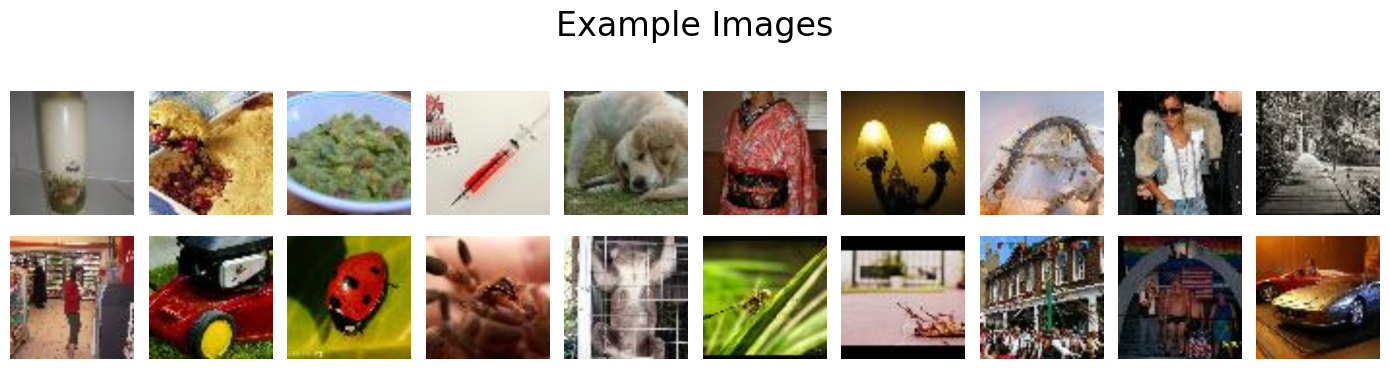

In [2]:
## Import dataset
transform = T.Compose([
    T.Resize((226, 226)),
    T.ToTensor()
])
imagenet_PATH = Path("DeepCluster/data/imagenet")
imagenet = TinyImageNet(imagenet_PATH, split="test", transform=transform)
print(imagenet)

plt.figure(figsize=(14, 4))
plt.suptitle("Example Images", fontsize=24)
for i, idx in enumerate(np.random.randint(low=0, high=10000, size=20)):
    img, _ = imagenet[i]
    plt.subplot(2, 10, i+1)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
alexnet = alexnet(weights="DEFAULT")
model = alexnet.features
summary(model=model, input_size=imagenet[0][0].shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
Total params: 2,469,696
Trainable param

In [10]:
def store_activations(model: nn.Module, img: Tensor, reduce_dims=False, verbose=False):
    layer_names = []
    for tpl in model.named_children():
        name = f"{tpl[0]}-{str(tpl[1]).split('(')[0]}"
        layer_names.append(name)
    
    ## Create forward hook
    activations = []
    def forward_hook(layer, image, out):
        activations.append(out)
        
    ## Register forward hooks
    for layer in model.modules():
        layer.register_forward_hook(forward_hook)
        
    ## Feed the image in the network forward
    with torch.no_grad():
        out = model(img)
        
    ## Return values in a dict with layers as keys
    activation_maps = {layer_names[i]:activations[i] for i in range(len(layer_names))}
    
    ## Apply dimensionality reduction for plotting.
    if reduce_dims:  ## For now, takes only the first 3 channels
        for key, tensor in activation_maps.items():
            img = tensor[:3]
            activation_maps[key] = img
            
    if verbose:  ## 
        print("Output Tensor Shapes of Layers:\n")
        for key, tensor in activation_maps.items():
            print(f"{key} : {tuple(tensor.shape)}")

    return activation_maps

In [14]:
img, label = imagenet[1200]
activation_maps = store_activations(model=model, img=img, verbose=True, reduce_dims=True)

Output Tensor Shapes of Layers:

0-Conv2d : (3, 55, 55)
1-ReLU : (3, 55, 55)
2-MaxPool2d : (3, 27, 27)
3-Conv2d : (3, 27, 27)
4-ReLU : (3, 27, 27)
5-MaxPool2d : (3, 13, 13)
6-Conv2d : (3, 13, 13)
7-ReLU : (3, 13, 13)
8-Conv2d : (3, 13, 13)
9-ReLU : (3, 13, 13)
10-Conv2d : (3, 13, 13)
11-ReLU : (3, 13, 13)
12-MaxPool2d : (3, 6, 6)


In [23]:
activation = activation_maps["4-ReLU"]
activation.shape

torch.Size([3, 27, 27])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


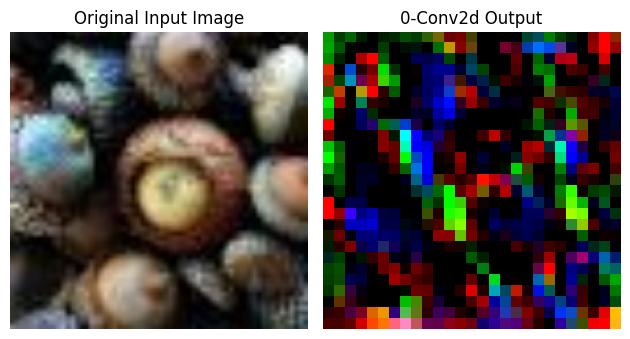

In [24]:
plt.subplot(1, 2, 1)
plt.title("Original Input Image")
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("0-Conv2d Output")
plt.imshow(activation.permute(1, 2, 0))
plt.axis("off")

plt.tight_layout()
plt.show()

## TODO:

#### Get top 10 most activating input images and plot

**`Probing deeper layers :`** We assess the quality of a target filter by learning an input image that maximizes its activation . We follow the process described by Yosinki et al. with a cross entropy function between the target filter and the other filters of the same layer. Figure 4 shows these synthetic images as well as the 9 top activated images from a subset of 1 million images from YFCC100M. As expected, deeper layers in the network seem to capture larger textural structures. However, some filters in the last convolutional layers seem to be simply replicating the texture already captured in previous layers...